# A pandemic shaped market

Two years, 505 trading days, 2 January 2020 to 31 December 2021. A volatility
spike to the highest close ever recorded, two emergency rate cuts twelve days
apart, a credit market that seized and then healed, and a recovery that ran
for eighteen months.

This notebook drives tradefloor with the **real macro path** from that period and
watches what comes out, tracking one large cap technology name through it.

It does not get there first time. The first attempt reproduces a crash on
entirely the wrong dates and far deeper than the real one, and most of the
notebook is the work of finding out why and fixing it, because that is the part
you would have to repeat on your own scenario.

## Read this first

**This is not a replay of 2020.** The simulator has never seen a price series.
It does not know what a pandemic is, that Apple exists, or that anything
happened in March 2020. What it is given is a handful of macro time series as
*inputs*; everything else is generated by the model.

| real, taken from the market | simulated, produced by the model |
|---|---|
| the VIX path | every share price |
| the Fed funds target | every volume |
| the Baa corporate bond yield, monthly | the drawdown and the recovery |
| the market valuation path | the reason behind each move |
| the business-cycle phase (NBER dates) | |
| Apple's FY2019 balance sheet | |

The fourth input in that left column, the market valuation path, is the one the
first attempt leaves out, and adding it is the repair.

**This notebook pins `pt-v12`. The shipped default is `pt-v20` (0.8.5).** The
repair feeds the market's valuation path in through `qe_pe_boost`, and from
`pt-v16` on that channel is switched off: `qe_pe_gain` is 0.0. The series that
drove it in calibration was this same proxy, the S&P against its own trend,
and it anticorrelates with measured Fed purchases at -0.485, so the channel
was closed rather than fitted to it. On `pt-v19` and `pt-v20` the repair
changes nothing.
`pt-v12` is the preset the figures below were written on, it is still
selectable, and it reproduces them. The last section runs the same path on
the default and shows what it does there.

## The inputs, and where they come from

Committed alongside this notebook in `data/covid-2020-2021.json`, so it runs
offline and gives the same answer every time. The market series are daily
closes retrieved from the Yahoo Finance chart API. The corporate yield is
Moody's Seasoned Baa Corporate Bond Yield, via FRED (DBAA), as monthly
values: the average of each month's daily observations, 24 of them.

| series | what it is | used as |
|---|---|---|
| `vix` | CBOE volatility index, daily close | model input |
| `baa_monthly` | Moody's Baa corporate bond yield, monthly average, percent | model input, interpolated to daily below |
| `spx` | S&P 500 close | model input from part 3 onward, and scored against |
| `aapl` | Apple close, adjusted for the 4-for-1 split of 31 August 2020 | scored against |

The file also carries `hyg`, the high-yield bond fund's close, which this
notebook no longer reads. The Fed funds path is not fetched. It is a step
function with two dates in it, taken from the FOMC statements themselves, and
stated in the code below.

In [1]:
import json
import datetime as dt
import math
import statistics as st

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow as pa
import pyarrow.compute as pc

import tradefloor as tf

# The preset this notebook was written on. "Read this first" says why it
# is pinned, and the last section runs the same path on the default.
MODEL = "pt-v12"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

RAW = json.load(open("data/covid-2020-2021.json"))
DATES = [dt.date.fromisoformat(d) for d in RAW["dates"]]
N = len(DATES)
AAPL, SPX = RAW["aapl"], RAW["spx"]

print(f"tradefloor {tf.version()}, preset {MODEL}, "
      f"shipped default {tf.model_preset()['name']}")
print(f"{N} trading days, {DATES[0]} to {DATES[-1]}")
print(f"VIX ranged {min(RAW['vix']):.2f} to {max(RAW['vix']):.2f}")
print(f"S&P 500 fell to {min(SPX):,.2f} and ended at {SPX[-1]:,.2f}")

tradefloor 0.8.5, preset pt-v12, shipped default pt-v20
505 trading days, 2020-01-02 to 2021-12-31
VIX ranged 12.10 to 82.69
S&P 500 fell to 2,237.40 and ended at 4,766.18


## Part 1: the obvious four legs

**Volatility** is the real VIX, used as is. Its peak of 82.69 on 16 March 2020
is the highest close in the index's history.

**Policy** is the FOMC target range midpoint. Two intermeeting cuts: 50bp on
3 March 2020 taking the range to 1.00-1.25%, then 100bp on 15 March taking it
to 0.00-0.25%, where it stayed for the rest of the period.

**Credit** is Moody's Baa corporate bond yield. The model reads its corporate
yield as investment grade: it is the rate fair value discounts at, and the
one the investment-grade bond index prices off. The file ships one value a
month, the month's average, and the path draws a straight line between them.
That keeps the level and the shape of 2020: 3.77% in January, 4.29% for March
and back under 3.7% by June. It loses the daily detail. Daily, Baa rose from
3.29% on 6 March to 5.15% on 20 March and was back at 4.63% by the month's
end; the monthly line peaks at 4.28% on 16 March.

pt-v20's registered row for this path, D2, drives the daily series, so this
notebook's credit leg is a smoothed version of the graded one.

Earlier versions of this notebook took the credit leg from the price of a
high-yield bond fund, HYG, converted to a yield through its duration. That
reproduced the high-yield index, 5.54% at the start and 11.4% at the peak on
23 March, and so discounted every name in the market at a high-yield rate.

**Quantitative easing** has no daily observable, so the first attempt shapes it
by hand: zero until the Fed announced unlimited purchases on 23 March 2020,
then ramping to a cap. This is the leg that goes wrong.

In [2]:
FIRST_CUT = dt.date(2020, 3, 3)    # 50bp, to 1.00-1.25%
SECOND_CUT = dt.date(2020, 3, 15)  # 100bp, to 0.00-0.25%
QE_START = dt.date(2020, 3, 23)    # unlimited purchases announced


def fed_funds(d):
    # FOMC target range midpoint.
    if d < FIRST_CUT:
        return 0.01625
    if d < SECOND_CUT:
        return 0.01125
    return 0.00125


def qe_shaped(d):
    # First attempt: zero until the announcement, then a ramp to the cap.
    if d < QE_START:
        return 0.0
    return min(0.10, 0.10 * (d - QE_START).days / 90)


# Moody's Baa, the yield fair value discounts at. The file ships one value a
# month, the month's average; each is placed on the 15th and the path is
# the straight line between them, flat before the first and after the last.
BAA = RAW["baa_monthly"]
ANCHORS = [(dt.date.fromisoformat(m + "-15"), y / 100)
           for m, y in zip(BAA["months"], BAA["percent"])]


def baa_on(d):
    if d <= ANCHORS[0][0]:
        return ANCHORS[0][1]
    for (d0, y0), (d1, y1) in zip(ANCHORS, ANCHORS[1:]):
        if d <= d1:
            return y0 + (y1 - y0) * (d - d0).days / (d1 - d0).days
    return ANCHORS[-1][1]


credit = [baa_on(d) for d in DATES]
policy = [fed_funds(d) for d in DATES]
qe_v1 = [qe_shaped(d) for d in DATES]

peak_i = max(range(N), key=lambda i: credit[i])
print(f"credit yield: {credit[0]:.2%} at the start")
print(f"              {credit[peak_i]:.2%} peak, on {DATES[peak_i]}")
print(f"              {credit[-1]:.2%} at the end")
print()
print(f"policy rate:  {policy[0]:.3%} -> {policy[-1]:.3%}, two cuts")

credit yield: 3.77% at the start
              4.28% peak, on 2020-03-16
              3.30% at the end

policy rate:  1.625% -> 0.125%, two cuts


Nothing in the credit leg was fitted: it is the published monthly average,
placed on the 15th of each month, with a straight line between months and the
first and last values held at the ends.

The path also carries the business-cycle phase, from the NBER dates and in
the model's own labels: peak to February 2020, contraction in March, trough
in April (the NBER trough month), recovery to April 2021 and expansion after.

In [3]:
def phases(dates):
    """The business-cycle phase each day, in the model's own labels, from the
    NBER dates: the expansion peaked in February 2020, contraction in March,
    trough in April (the NBER trough month), recovery until output passed
    its old high in the spring of 2021, and expansion after. A macro path
    that leaves the cycle out lets the model's own cycle run, and on pt-v20,
    whose earnings follow the cycle, that kept the economy in contraction
    through 2021."""
    out = []
    for d in dates:
        if d < dt.date(2020, 3, 1):
            out.append("peak")
        elif d < dt.date(2020, 4, 1):
            out.append("contraction")
        elif d < dt.date(2020, 5, 1):
            out.append("trough")
        elif d < dt.date(2021, 5, 1):
            out.append("recovery")
        else:
            out.append("expansion")
    return out


PHASE = phases(DATES)


def build(qe):
    path = [{"day": i, "vix": RAW["vix"][i], "federal_funds_rate": policy[i],
             "corporate_bond_yield": credit[i], "qe_pe_boost": qe[i],
             "cycle": PHASE[i]}
            for i in range(N)]
    return tf.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "covid 2020-2021", "days": N, "path": path}))


def make_universe():
    # Apple's FY2019 accounts, restated for the 4-for-1 split of 31 Aug 2020.
    aapl = tf.Instrument(
        "AAPL", "technology",
        initial_price=AAPL[0],       # real close on 2 January 2020
        shares_outstanding=17.77e9,  # ~4.44bn pre-split
        eps=2.97,                    # $11.89 diluted, restated
        book_value_per_share=5.09,   # $90.5bn equity, restated
        revenue_growth=-0.02,        # FY2019 revenue fell 2%
        avg_volume=140e6, beta=1.2, short_interest=124e6,
    )
    u = tf.Universe([aapl])
    u.extend(tf.Universe.random(39, seed=2020))
    return u


def run(scenario, universe=None, seed=2020, model=MODEL):
    e = tf.Engine(seed=seed, universe=universe or make_universe(),
                  model=model)
    for i in range(N):
        scenario.apply(e, i)
        e.run_days(1, first_day=i)
    return e


def closes(engine, iid=0):
    b = pa.table(engine.bars(grain="day"))
    return pc.filter(b, pc.equal(b["instrument_id"], iid))["close"].to_pylist()


def index_of(engine):
    b = pa.table(engine.bars(grain="day"))
    last = pc.filter(b, pc.equal(b["bar"], pc.max(b["bar"])))
    return (last.group_by("day").aggregate([("close", "mean")])
            .sort_by("day")["close_mean"].to_pylist())


engine1 = run(build(qe_v1))
sim1, idx1 = closes(engine1), index_of(engine1)
print(f"model {engine1.model_fingerprint}, {N} days")
print(f"AAPL ${sim1[0]:,.2f} -> ${sim1[-1]:,.2f}  ({sim1[-1] / sim1[0] - 1:+.1%})")

model pt-v12, 505 days
AAPL $73.65 -> $88.94  (+20.8%)


### Scoring the first attempt

In [4]:
def rets(x):
    return [x[i] / x[i - 1] - 1 for i in range(1, len(x))]


def corr(a, b):
    ma, mb = st.mean(a), st.mean(b)
    va = sum((v - ma) ** 2 for v in a) ** 0.5
    vb = sum((v - mb) ** 2 for v in b) ** 0.5
    return sum((v - ma) * (w - mb) for v, w in zip(a, b)) / (va * vb)


def max_drawdown(x):
    peak, worst, at = x[0], 0.0, 0
    for i, v in enumerate(x):
        peak = max(peak, v)
        if v / peak - 1 < worst:
            worst, at = v / peak - 1, i
    return worst, at


def scorecard(sim, idx, title):
    w, at = max_drawdown(sim)
    wa, ata = max_drawdown(AAPL)
    print(title)
    print("-" * 62)
    print(f"{'':30s} {'simulated':>14s} {'actual':>14s}")
    print(f"{'annualised volatility':30s} "
          f"{st.pstdev(rets(sim)) * 252 ** 0.5:>14.1%} "
          f"{st.pstdev(rets(AAPL)) * 252 ** 0.5:>14.1%}")
    print(f"{'maximum drawdown':30s} {w:>14.1%} {wa:>14.1%}")
    print(f"{'date of the trough':30s} {str(DATES[at]):>14s} {str(DATES[ata]):>14s}")
    print(f"{'total return':30s} {sim[-1] / sim[0] - 1:>+14.1%} "
          f"{AAPL[-1] / AAPL[0] - 1:>+14.1%}")
    print()
    print(f"{'AAPL, level correlation':30s} {corr(sim, AAPL):>+14.3f}")
    print(f"{'AAPL, daily return corr':30s} {corr(rets(sim), rets(AAPL)):>+14.3f}")
    print(f"{'index vs S&P, level corr':30s} {corr(idx, SPX):>+14.3f}")
    print(f"{'index vs S&P, daily corr':30s} {corr(rets(idx), rets(SPX)):>+14.3f}")


scorecard(sim1, idx1, "First attempt: four macro legs")

First attempt: four macro legs
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   58.7%          37.4%
maximum drawdown                       -51.8%         -31.4%
date of the trough                 2020-05-13     2020-03-23
total return                           +20.8%        +136.5%

AAPL, level correlation                +0.262
AAPL, daily return corr                -0.048
index vs S&P, level corr               +0.244
index vs S&P, daily corr               -0.030


### That is a failure, and a specific one

The drawdown is real and it is far too deep: -51.8% against Apple's -31.4%.
The date is not close at all.

The real trough was 23 March 2020. The simulated one is 13 May, roughly seven
weeks late. A drawdown that deep arriving seven weeks after the crisis is not a
crisis reproduced, it is a crisis sized move that happens to land in the same
year.

The daily return correlation, -0.048 against Apple, says the same thing more
bluntly. So something that moved markets in March 2020 is not reaching the
model. The useful question is which channel is missing, and measurable.

## Part 2: which field actually moves a valuation?

Rather than guess, sweep each macro field on its own and watch what happens to
`fundamental_value`, the model's view of what a company is worth. Everything
else is held fixed, so whatever moves is the channel. Everything in this part
is measured on `pt-v12`, the preset this notebook pins.

**The horizon matters for two of these fields, and getting it wrong is easy.**
An earlier version of this notebook ran the probe over two days and concluded
that the policy rate does nothing. It does. The corporate bond yield, which is
the rate equities actually discount off, is recomputed only at central bank
meetings, and the first is scheduled 45 days out. Before then a policy path has
nothing to steer, so a short probe measures the meeting schedule and reports it
as an absence.

The boundary is sharp rather than gradual. Holding everything else fixed, a
policy rate of 0.5% against 10% gives bit identical valuations through day 44,
and the whole gap, 11.7% of fundamental value here, opens in a single step on
day 45. Day 0 is the first session, which is the numbering a `Scenario` path
uses and the numbering `docs/scenario-recipes.md` means when it states the rule
as "a policy-only rate path does nothing before day 45". The boundary is a
`pt-v12` fact. On `pt-v19`, the default in 0.8.0 and 0.8.1, the same pair is bit identical through
day 7 and the gap then builds over about ten sessions: -0.28% through day 8
and -10.2% through day 19.

**This is not a general property of scenarios, and it would be easy to take it
as one.** Most of the surface transmits the day you move it. Measured on
`pt-v12` over `Universe.random(20, seed=4)` at seed 5, pinning one field from
day 5 in one market and holding it at its base value in the other, and
reading the median instrument at the close of day 25:

| field | median price move | median fair-value move |
|---|---|---|
| `qe_pe_boost` 0 to -0.30 | -27.44% | -30.00% |
| `vix` 15 to 60 | -15.27% | 0.00% |
| `inflation_rate` 2% to 9% | -10.79% | -10.56% |
| `corporate_bond_yield` 3.77% to 4.28% (Baa's 2020 rise, monthly) | -0.63% | -0.92% |
| `federal_funds_rate` 1.625% to 10% | 0.00% | 0.00% |
| `fear_greed_index` 50 to 0 | 0.00% | 0.00% |

The `vix` row is a draw rather than a direction: VIX widens the market
factor without touching fair value at all. `federal_funds_rate` is the only
field with no route to price before the first meeting, so it reads exactly
0.00% there. `fear_greed_index` reads 0.00% too, for the opposite reason:
nothing reads it, at any horizon.

`inflation_rate` looks like a second slow field and is not. It too reaches
price only by steering the yield, but a step to 9% leaves inflation more than
4pp above the policy rate, which makes the bank skip its own calendar: the
yield has moved by the close of day 5, the day of the shock, forty days
before the first scheduled meeting. What severs it is a pinned
`corporate_bond_yield`, which is exactly what the sweep below does.

The sweep below runs 120 days, past the first meeting.

In [5]:
PROBE_DAYS = 120   # long enough for the slow channels to show up
BASE = dict(vix=15.0, federal_funds_rate=0.01625,
            corporate_bond_yield=credit[0], qe_pe_boost=0.0)


def fundamental(days=PROBE_DAYS, drop=(), **over):
    f = {k: v for k, v in {**BASE, **over}.items() if k not in drop}
    s = tf.Scenario.from_json(json.dumps(
        {"schema": 1, "label": "probe", "days": days,
         "path": [dict(day=i, **f) for i in range(days)]}))
    # A small universe: the probe only reads instrument 0's valuation, and
    # thirteen 120 day runs over forty names is a minute of nothing.
    small = tf.Universe([make_universe()[0]])
    small.extend(tf.Universe.random(4, seed=4))
    e = tf.Engine(seed=2020, universe=small, model=MODEL)
    for i in range(days):
        s.apply(e, i)
        e.run_days(1, first_day=i)
    t = pa.table(e.truth())
    one = pc.filter(t, pc.equal(t["instrument_id"], 0))
    one = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
    return one[-1]["fundamental_value"]


base = fundamental()
print(f"baseline fundamental value at {PROBE_DAYS} days: ${base:,.2f}\n")
print(f"{'field':24s} {'swept to':>10s} {'fundamental':>13s} {'change':>9s}")
print("-" * 60)

for field, vals in [
    ("qe_pe_boost", [-0.30, -0.10, 0.10, 0.30]),
    ("corporate_bond_yield", [0.03, max(credit), 0.114, 0.20]),
    ("vix", [12.0, 40.0, 82.69]),
    ("federal_funds_rate", [0.0, 0.05, 0.10]),
]:
    for v in vals:
        f = fundamental(**{field: v})
        print(f"{field:24s} {v:>10.4f} {f:>13,.2f} {f / base - 1:>+8.1%}")
    print()

baseline fundamental value at 120 days: $95.37

field                      swept to   fundamental    change
------------------------------------------------------------


qe_pe_boost                 -0.3000         66.76   -30.0%


qe_pe_boost                 -0.1000         85.83   -10.0%


qe_pe_boost                  0.1000        104.90   +10.0%


qe_pe_boost                  0.3000        123.98   +30.0%



...

vix                         40.0000         95.37    +0.0%


vix                         82.6900         95.37    +0.0%



federal_funds_rate           0.0000         95.37    +0.0%


federal_funds_rate           0.0500         95.37    +0.0%


federal_funds_rate           0.1000         95.37    +0.0%



Two of those read as flat zeros, the same answer the two day probe gave. The
zeros are real but **conditional**, and the condition is in the baseline:
`corporate_bond_yield` is pinned there.

Unpin it and the policy rate reappears.

In [6]:
free = fundamental(drop=("corporate_bond_yield",))
print("federal_funds_rate, with corporate_bond_yield NOT pinned")
print(f"{'':26s} {'fundamental':>13s} {'change':>9s}")
print("-" * 52)
for v in (0.0, 0.05, 0.10):
    f = fundamental(drop=("corporate_bond_yield",), federal_funds_rate=v)
    print(f"  rate {v:>6.3%}{'':11s} {f:>13,.2f} {f / free - 1:>+8.1%}")

federal_funds_rate, with corporate_bond_yield NOT pinned
                             fundamental    change
----------------------------------------------------


  rate 0.000%                    97.00    +2.4%


  rate 5.000%                    90.37    -4.6%


  rate 10.000%                    84.98   -10.3%


### The finding

**The model has exactly two valuation channels, and they are not symmetric.**

**`corporate_bond_yield` is the discount rate**, and the only route the
other macro fields have. `federal_funds_rate`, `vix` and `inflation_rate` reach
fundamental value *solely* by moving it, and they move it only when the central
bank next meets. That is why they read as zero above: the baseline pins the
yield, which severs every upstream field from the one thing they act through.
Unpinned, a policy rate of 10% costs about 10% of fundamental value, so the
channel is strong. It is conditional on the yield being free, and it arrives on
a meeting schedule rather than continuously.

**`qe_pe_boost` is a direct multiple**, and it bypasses the yield entirely. It
moves fundamental value one for one: set it to -0.30 and the valuation falls
30%. It accepts negative values, as this notebook needs.

The practical consequence for this notebook is specific. Its credit leg is
pinned to something real, Moody's Baa. Pinning it means the
policy path and the VIX path can no longer re-rate anything, so the whole
burden of expressing a valuation move falls on `qe_pe_boost`, set to
zero through the crash.

Sizing it against 2020 settles whether that is enough to explain the miss.

Each leg is now given the move it actually made in 2020, one at a time, against
the 34% the S&P actually fell.

In [7]:
print(f"the real S&P 500 fell {min(SPX) / max(SPX[:60]) - 1:.1%} peak to trough\n")
print(f"{'each 2020 sized move, on its own':44s} {'effect':>9s}")
print("-" * 56)
for label, over in [
    ("federal_funds_rate 1.625% -> 0.125% (a cut)", dict(federal_funds_rate=0.00125)),
    (f"corporate_bond_yield {credit[0]:.2%} -> {max(credit):.2%}",
     dict(corporate_bond_yield=max(credit))),
    ("vix 15 -> 82.69", dict(vix=82.69)),
    ("qe_pe_boost 0 -> -0.30", dict(qe_pe_boost=-0.30)),
]:
    print(f"{label:44s} {fundamental(**over) / base - 1:>+8.1%}")

the real S&P 500 fell -33.9% peak to trough

each 2020 sized move, on its own                effect
--------------------------------------------------------


federal_funds_rate 1.625% -> 0.125% (a cut)     +0.0%


corporate_bond_yield 3.77% -> 4.28%             -0.8%


vix 15 -> 82.69                                 +0.0%


qe_pe_boost 0 -> -0.30                         -30.0%


The real 2020 moves in the policy rate and the VIX buy nothing while the credit
leg is pinned, and the credit leg itself, over its 2020 rise from 3.77% to
4.28% as a monthly series, is worth about 1%. The version of this notebook
that drove Baa's daily series, 3.86% to its 5.15% peak, measured about 2%.
The high-yield proxy earlier versions used, 11.4%
at its peak, is worth 11.4% on the same baseline. Against a 34% fall, the
three legs the first attempt varied could not produce the crash between
them.

Only `qe_pe_boost` is capable of expressing a de-rating of that size, and it
was pinned at **zero through the whole crash**, then ramped *upward*
afterwards. The model was told the market got more expensive after March 2020
and never told it got cheaper during it.

## Part 3: giving it the valuation path

`qe_pe_boost` is a valuation premium, so drive it with the market's actual
valuation swing: the real S&P against its own slow trend. Above trend is a rich
market, below trend is a cheap one.

The trend is a 200 day exponential moving average, and the result is clamped to
plus or minus 35% so that no single day can drive the whole market to zero.

**Be clear about what this changes.** The market wide valuation path is now an
*input*, taken from the real S&P. The simulated index therefore tracks the real
index partly by construction, and its correlation is no longer independent
evidence. The number that still means something is AAPL: a single name whose
own path is simulated, given the market it traded in. This is the ordinary
shape of a factor model, where the market factor is supplied and the
idiosyncratic part is not.

In [8]:
CAP = 0.35
EMA_SPAN = 200


def ema(x, span):
    k = 2 / (span + 1)
    out = [x[0]]
    for v in x[1:]:
        out.append(out[-1] + k * (v - out[-1]))
    return out


trend = ema(SPX, EMA_SPAN)
qe_v2 = [max(-CAP, min(CAP, SPX[i] / trend[i] - 1)) for i in range(N)]

lo, hi = min(qe_v2), max(qe_v2)
print(f"valuation premium ranged {lo:+.1%} to {hi:+.1%}")
print(f"  cheapest on {DATES[qe_v2.index(lo)]}")
print(f"  richest  on {DATES[qe_v2.index(hi)]}")

valuation premium ranged -29.6% to +14.5%
  cheapest on 2020-03-23
  richest  on 2021-04-16


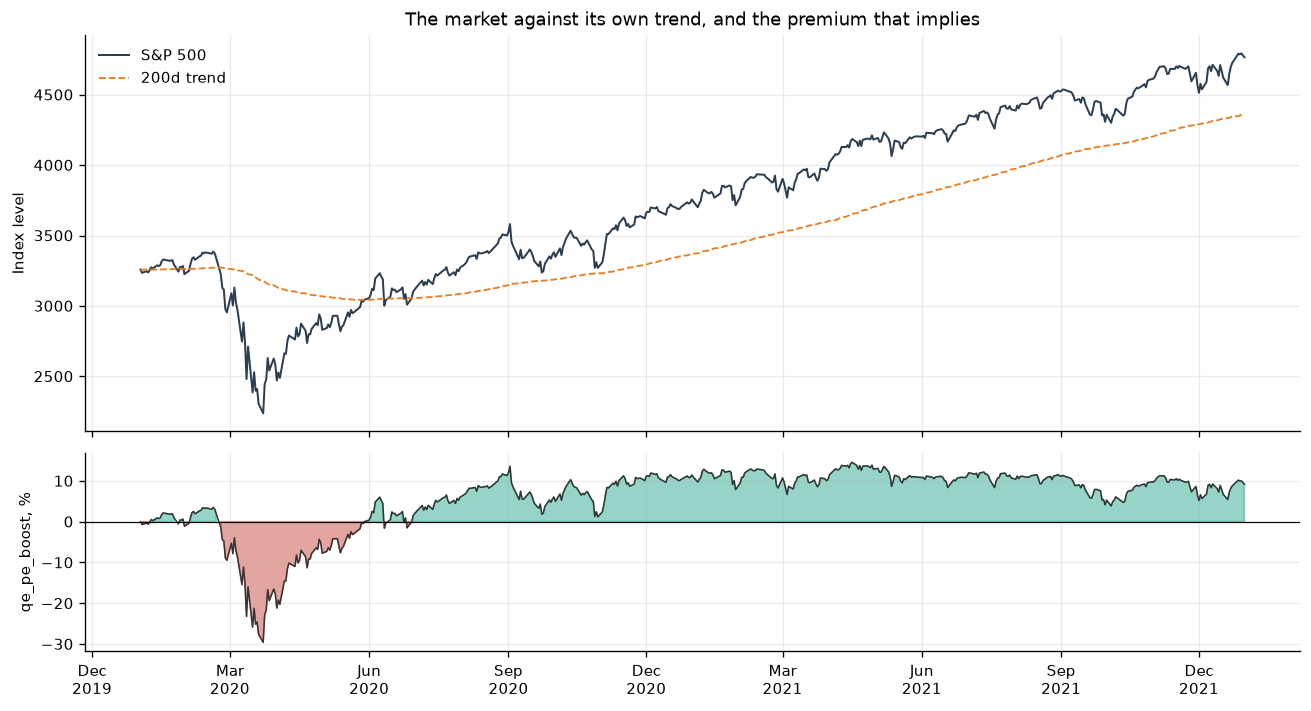

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(DATES, SPX, color="#2c3e50", lw=1.2, label="S&P 500")
ax1.plot(DATES, trend, color="#e67e22", lw=1.1, ls="--",
         label=f"{EMA_SPAN}d trend")
ax1.set_ylabel("Index level")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("The market against its own trend, and the premium that implies",
              fontsize=11)

ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q >= 0 for q in qe_v2], color="#16a085", alpha=0.45)
ax2.fill_between(DATES, [q * 100 for q in qe_v2], 0,
                 where=[q < 0 for q in qe_v2], color="#c0392b", alpha=0.45)
ax2.plot(DATES, [q * 100 for q in qe_v2], color="#333", lw=0.9)
ax2.axhline(0, color="black", lw=0.7)
ax2.set_ylabel("qe_pe_boost, %")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

In [10]:
engine2 = run(build(qe_v2))
sim2, idx2 = closes(engine2), index_of(engine2)
scorecard(sim2, idx2, "Second attempt: with the real valuation path")

Second attempt: with the real valuation path
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   63.5%          37.4%
maximum drawdown                       -49.3%         -31.4%
date of the trough                 2020-05-13     2020-03-23
total return                           +19.3%        +136.5%

AAPL, level correlation                +0.614
AAPL, daily return corr                +0.269
index vs S&P, level corr               +0.479
index vs S&P, daily corr               +0.392


In [11]:
rows = [
    ("AAPL, level correlation", corr(sim1, AAPL), corr(sim2, AAPL), None),
    ("AAPL, daily return corr", corr(rets(sim1), rets(AAPL)),
     corr(rets(sim2), rets(AAPL)), None),
    ("index vs S&P, daily corr", corr(rets(idx1), rets(SPX)),
     corr(rets(idx2), rets(SPX)), None),
    ("maximum drawdown", max_drawdown(sim1)[0], max_drawdown(sim2)[0],
     max_drawdown(AAPL)[0]),
]

print(f"{'':30s} {'attempt 1':>12s} {'attempt 2':>12s} {'actual':>12s}")
print("-" * 70)
for name, a, b, actual in rows:
    fa = f"{a:+.3f}" if actual is None else f"{a:.1%}"
    fb = f"{b:+.3f}" if actual is None else f"{b:.1%}"
    fc = "" if actual is None else f"{actual:.1%}"
    print(f"{name:30s} {fa:>12s} {fb:>12s} {fc:>12s}")

t1, t2 = max_drawdown(sim1)[1], max_drawdown(sim2)[1]
print(f"{'date of the trough':30s} {str(DATES[t1]):>12s} {str(DATES[t2]):>12s} "
      f"{str(DATES[max_drawdown(AAPL)[1]]):>12s}")

                                  attempt 1    attempt 2       actual
----------------------------------------------------------------------
AAPL, level correlation              +0.262       +0.614             
AAPL, daily return corr              -0.048       +0.269             
index vs S&P, daily corr             -0.030       +0.392             
maximum drawdown                     -51.8%       -49.3%       -31.4%
date of the trough               2020-05-13   2020-05-13   2020-03-23


### What the repair bought, and what it did not

Daily returns go from uncorrelated to correlated: -0.048 to +0.269 against
Apple, and -0.030 to +0.392 for the index against the S&P. The level
correlation against Apple goes from +0.262 to +0.614. Attempt one's daily
moves had nothing to do with Apple's; attempt two's move with them.

**The trough does not move.** Both attempts put it on 13 May, seven weeks
after the real one. An earlier version of this notebook, pinned to `pt-v6`,
had the valuation path pull the trough onto 23 March exactly; on `pt-v12` it
does not. The date is a single draw from one
seed and it moves around. The correlations, which average over 505 days rather
than picking one, are the part worth reading.

**It is not free either.** Realised volatility overshoots, and the repair makes
it worse: attempt one comes out at 58.7% against Apple's 37.4%, and attempt two
at 63.5%. Feeding a valuation path derived from a real, jumpy index injects
that index's variance into fair value, so prices now move for two reasons where
the real market had one. The depth barely moves either, -51.8% to -49.3%
against Apple's -31.4%. The trade is a large gain in correlation for a real
loss in volatility calibration.

Smoothing the valuation path is the obvious remedy and it does not work.
Averaged over the last two days, it takes the volatility from 63.5% to 59.6%
and the daily correlation with Apple from +0.269 to +0.060. Over five days
the volatility is 57.5% and the correlation +0.002, and longer windows leave
the volatility near 58% with the correlation at or below zero. The
jumpiness is what carries the timing, so the overshoot is kept.

Two other things to keep in view. The index correlation is partly built in now,
as noted above. And the two year total return is still far short of Apple's,
which no amount of macro will fix, for reasons the last section returns to.

## The question behind all of this: do the effects follow the causes?

Everything scored so far compares two PATHS, and a path can agree by luck. The
sharper question is whether the simulated market responds to each driver the
way the real one responded to that same driver. Same inputs, same window, two
responses, four channels each with a sign that theory fixes in advance.

The comparison to watch is against real **AAPL**, not the S&P. The drivers are
market wide, and the valuation leg is derived from the S&P itself, so the
index's numbers are close to definitional. AAPL is a single name that has to
earn its correlation.

In [12]:
def diffs(x):
    return [x[i] - x[i - 1] for i in range(1, len(x))]


r_sim, r_real, r_spx = rets(sim2), rets(AAPL), rets(SPX)
d_vix, d_credit = diffs(RAW["vix"]), diffs(credit)
d_val = diffs(qe_v2)

print(f"{'channel':42s} {'simulated':>10s} {'real AAPL':>10s} {'real S&P':>9s}")
print("-" * 74)
for label, driver in (
    ("return vs change in VIX          (expect <0)", d_vix),
    ("return vs change in credit yield (expect <0)", d_credit),
    ("return vs change in valuation    (expect >0)", d_val),
):
    print(f"{label:42s} {corr(r_sim, driver):>+10.3f} "
          f"{corr(r_real, driver):>+10.3f} {corr(r_spx, driver):>+9.3f}")

av = RAW["vix"][1:]
print(f"{'|return| vs VIX level            (expect >0)':42s} "
      f"{corr([abs(x) for x in r_sim], av):>+10.3f} "
      f"{corr([abs(x) for x in r_real], av):>+10.3f} "
      f"{corr([abs(x) for x in r_spx], av):>+9.3f}")

channel                                     simulated  real AAPL  real S&P
--------------------------------------------------------------------------
return vs change in VIX          (expect <0)     -0.272     -0.622    -0.788
return vs change in credit yield (expect <0)     -0.050     -0.150    -0.191
return vs change in valuation    (expect >0)     +0.380     +0.803    +0.990
|return| vs VIX level            (expect >0)     +0.507     +0.489    +0.725


In [13]:
STUDY = [
    (dt.date(2020, 2, 19), "S&P peak, selloff begins"),
    (dt.date(2020, 3, 3),  "Fed emergency cut 50bp"),
    (dt.date(2020, 3, 16), "VIX record close 82.69"),
    (dt.date(2020, 3, 23), "trough, unlimited QE"),
    (dt.date(2020, 11, 9), "vaccine efficacy"),
    (dt.date(2021, 11, 26), "Omicron"),
]
W_EV = 5

print(f"cumulative return over the {W_EV} sessions after each event\n")
print(f"{'event':32s} {'simulated':>10s} {'real AAPL':>10s} {'agree?':>8s}")
print("-" * 64)
agree = 0
for d, name in STUDY:
    i = DATES.index(d)
    j = min(i + W_EV, N - 1)
    s, r = sim2[j] / sim2[i] - 1, AAPL[j] / AAPL[i] - 1
    ok = (s >= 0) == (r >= 0)
    agree += ok
    print(f"{name:32s} {s:>+10.1%} {r:>+10.1%} {'yes' if ok else 'NO':>8s}")
print(f"\nsign agreement: {agree}/{len(STUDY)}")

cumulative return over the 5 sessions after each event

event                             simulated  real AAPL   agree?
----------------------------------------------------------------
S&P peak, selloff begins             -11.2%      -9.6%      yes
Fed emergency cut 50bp               +10.9%      -1.4%       NO
VIX record close 82.69                +4.2%      -7.4%       NO
trough, unlimited QE                 +19.3%     +13.6%      yes
vaccine efficacy                      -0.9%      +3.4%       NO
Omicron                               -2.4%      +3.2%       NO

sign agreement: 2/6


### What that says, including the ones it gets wrong

**All four channels carry the sign theory fixes.** A market that re-rated
upward when volatility rose or credit tightened would be broken in a way no
amount of path-matching would reveal.

**The credit row reads a smoothed series.** Baa enters as a monthly average
with a straight line between months, so its daily change is the same small
number for weeks at a time, and the row measures how returns lean over whole
months of rising or falling yield. Read that way the simulated market
agrees in sign with the real one, -0.050 against -0.150 for AAPL and -0.191
for the S&P. Part 2 measures the channel directly instead: Baa's monthly 2020
rise is worth about 1% of fundamental value.

**The volatility channel is the strongest.** Clustering against the VIX level
reads +0.507 simulated against +0.489 for real AAPL: feed this model a
volatility path and it becomes turbulent when it should, by about the right
amount, and slightly more than Apple did.

**The directional channels carry the right sign, and a correlation does not
measure how far.** Reading -0.272 against AAPL's -0.622 as less than half the
response is the inference the realism envelope withdrew from its
`scenario-magnitude` gap: a correlation is beta times sd(driver) over
sd(return), so it reports the SHARE of a move a driver explains rather than
the gain applied to it. Measured as gains instead -- the OLS slope of daily
return on each driver, over that gap's own driven window -- it records the
VIX, credit and valuation channels on `pt-v12` within about ten percent of
real AAPL's, and the model's residual sd at about 1.57x the real stock's. The
denominator is the defect rather than the gain: the same response is a
smaller share of a noisier return.

Those are the gap's numbers and not this run's, and the two are not the same
draw. The gap's window drives the credit leg with the high-yield proxy this
notebook used before, not with the monthly Baa. Against the same real AAPL column, the
gap reports -0.423, -0.496 and +0.573 on the three directional channels
(`pt-v3`, 2026-08-25) where the cell above prints -0.272, -0.050 and +0.380.
Nothing here reconciles them: read the gap for the argument about what a
correlation measures, and this table for what this seed did.

**Two of six events agree on sign, and the misses are informative.**

The Fed cut goes the wrong way. On 3 March 2020 the Fed cut 50bp between
meetings; the simulated market gained 10.9% over the following week and Apple
lost 1.4%. The model treats a cut as unambiguously good for equities, the
textbook channel, which is usually right. What it has no representation of is
an emergency cut reading as a *panic signal*, where the information in the
decision to move early outweighs the rate itself. The channel is missing
rather than miscalibrated, which matters if you are using this to study policy
surprises.

The record VIX close misses too. The simulated market rose 4.2% over the
following five sessions, where Apple fell 7.4%.

The two late events, the vaccine result and Omicron, go the other way: the
simulated market drifts down 0.9% and 2.4% while Apple gained 3.4% and 3.2%.
Those are single-stock news events for Apple; nothing in this run tells the
model that a vaccine is good for one company in particular, and its index is
driven entirely by the macro path it was handed. A one-name event study on
macro inputs is the wrong instrument for them, which the agreement count makes
visible rather than hiding.

The two that agree are the ones the macro path can carry: the February selloff
and the trough with unlimited QE.

## The simulated share price, against the volatility it was handed

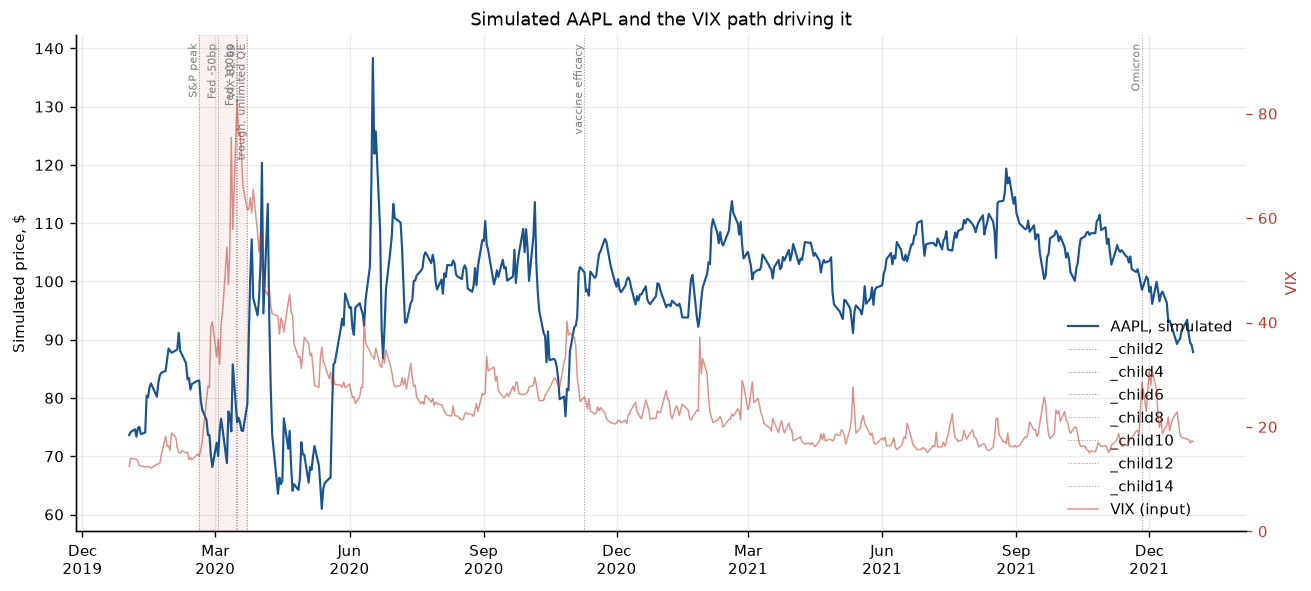

In [14]:
EVENTS = [
    (dt.date(2020, 2, 19), "S&P peak"),
    (dt.date(2020, 3, 3),  "Fed -50bp"),
    (dt.date(2020, 3, 15), "Fed -100bp"),
    (dt.date(2020, 3, 16), "VIX 82.69"),
    (dt.date(2020, 3, 23), "trough, unlimited QE"),
    (dt.date(2020, 11, 9), "vaccine efficacy"),
    (dt.date(2021, 11, 26), "Omicron"),
]
crash = (dt.date(2020, 2, 19), dt.date(2020, 3, 23))

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, sim2, color="#1a5490", lw=1.3, label="AAPL, simulated", zorder=3)
ax.set_ylabel("Simulated price, $")

vax = ax.twinx()
vax.plot(DATES, RAW["vix"], color="#c0392b", lw=0.9, alpha=0.55,
         label="VIX (input)", zorder=2)
vax.set_ylabel("VIX", color="#c0392b")
vax.tick_params(axis="y", colors="#c0392b")
vax.grid(False)
vax.set_ylim(0, 95)

for d, name in EVENTS:
    ax.axvline(d, color="grey", lw=0.6, ls=":", alpha=0.8)
    ax.text(d, ax.get_ylim()[1] * 0.99, name, rotation=90, fontsize=6.5,
            ha="right", va="top", color="grey")

lines = ax.get_lines() + vax.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Simulated AAPL and the VIX path driving it", fontsize=11)
fig.tight_layout()
plt.show()

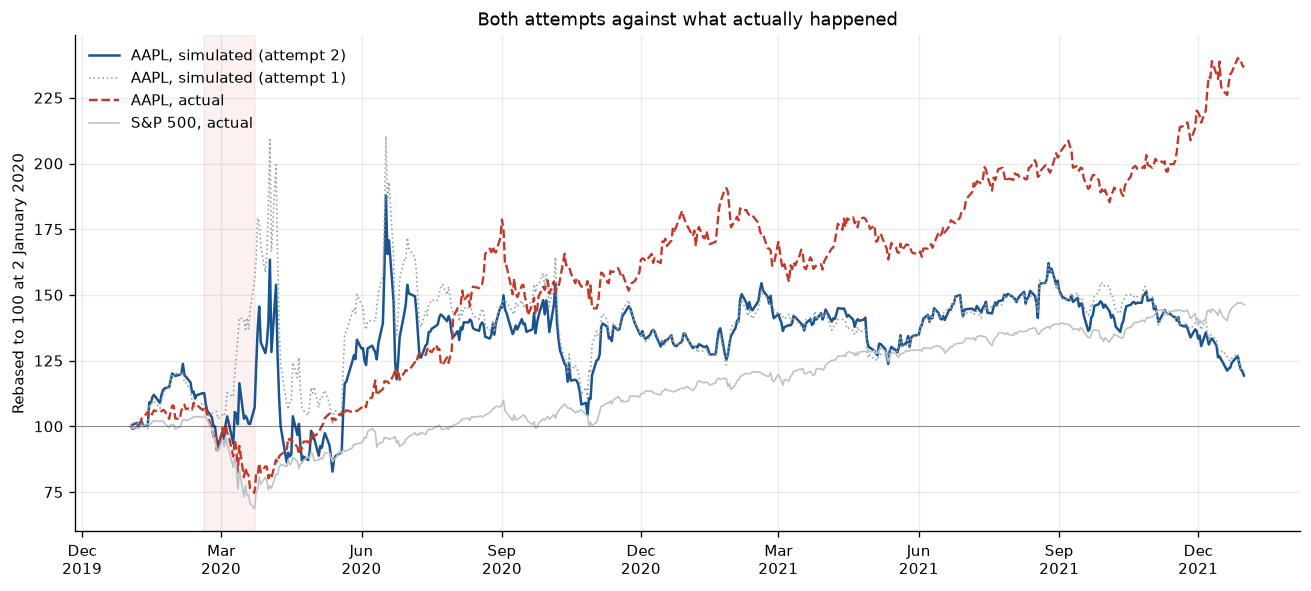

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.plot(DATES, [100 * p / sim2[0] for p in sim2],
        color="#1a5490", lw=1.5, label="AAPL, simulated (attempt 2)")
ax.plot(DATES, [100 * p / sim1[0] for p in sim1],
        color="#95a5a6", lw=1.0, ls=":", label="AAPL, simulated (attempt 1)")
ax.plot(DATES, [100 * p / AAPL[0] for p in AAPL],
        color="#c0392b", lw=1.4, ls="--", label="AAPL, actual")
ax.plot(DATES, [100 * p / SPX[0] for p in SPX],
        color="#bdc3c7", lw=1.0, label="S&P 500, actual")
ax.axhline(100, color="black", lw=0.6, alpha=0.4)
ax.set_ylabel("Rebased to 100 at 2 January 2020")
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Both attempts against what actually happened", fontsize=11)
fig.tight_layout()
plt.show()

## The drawdown, and how long recovery took

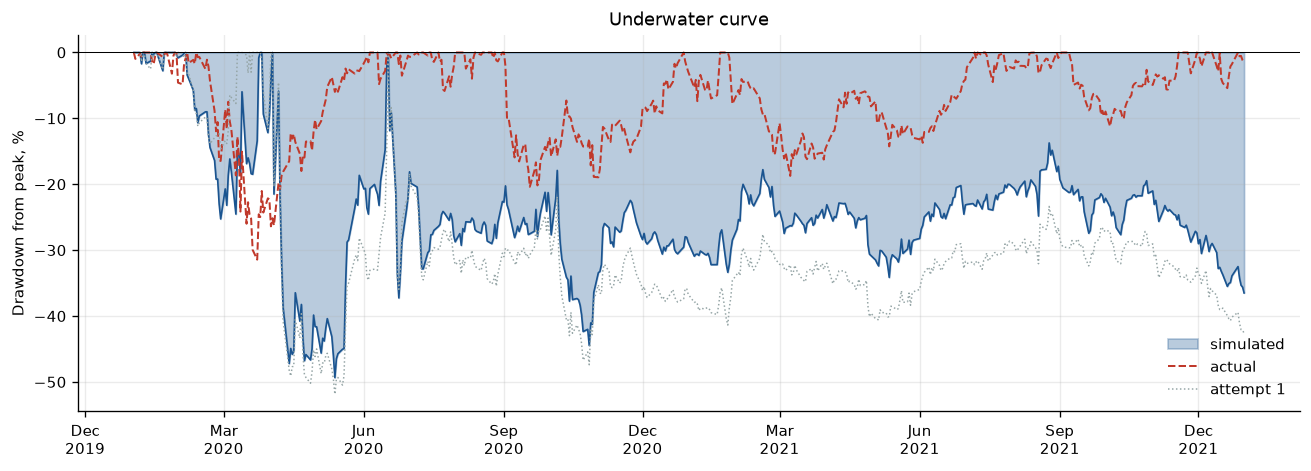

In [16]:
def underwater(x):
    peak, out = x[0], []
    for v in x:
        peak = max(peak, v)
        out.append(100 * (v / peak - 1))
    return out


fig, ax = plt.subplots(figsize=(11, 4))
uw2, uwr, uw1 = underwater(sim2), underwater(AAPL), underwater(sim1)
ax.fill_between(DATES, uw2, 0, color="#1a5490", alpha=0.30, label="simulated")
ax.plot(DATES, uw2, color="#1a5490", lw=1.0)
ax.plot(DATES, uwr, color="#c0392b", lw=1.2, ls="--", label="actual")
ax.plot(DATES, uw1, color="#95a5a6", lw=0.9, ls=":", label="attempt 1")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("Drawdown from peak, %")
ax.legend(loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Underwater curve", fontsize=11)
fig.tight_layout()
plt.show()

## Did the model's realised volatility follow the VIX it was given?

The VIX is an input, not an outcome. Whether the market that comes out actually
*is* more volatile when told to be is a property of the model, and worth
checking rather than assuming.

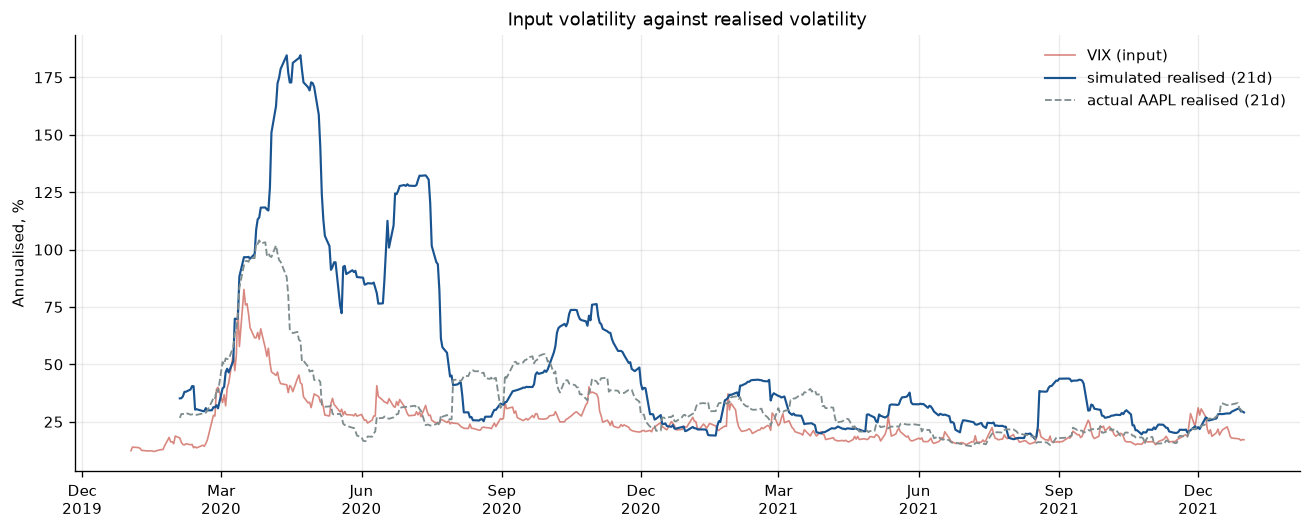

simulated realised vol against the VIX input: +0.645
actual AAPL realised vol against the VIX:     +0.816


In [17]:
W = 21


def rolling_vol(x, w=W):
    r = rets(x)
    return [None] * w + [st.pstdev(r[i - w:i]) * 252 ** 0.5 * 100
                         for i in range(w, len(r) + 1)]


rv_sim, rv_real = rolling_vol(sim2), rolling_vol(AAPL)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(DATES, RAW["vix"], color="#c0392b", lw=1.0, alpha=0.6, label="VIX (input)")
ax.plot(DATES, rv_sim, color="#1a5490", lw=1.3, label=f"simulated realised ({W}d)")
ax.plot(DATES, rv_real, color="#7f8c8d", lw=1.1, ls="--",
        label=f"actual AAPL realised ({W}d)")
ax.set_ylabel("Annualised, %")
ax.legend(loc="upper right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Input volatility against realised volatility", fontsize=11)
fig.tight_layout()
plt.show()

pairs = [(a, b) for a, b in zip(rv_sim, RAW["vix"]) if a is not None]
print(f"simulated realised vol against the VIX input: "
      f"{corr([a for a, _ in pairs], [b for _, b in pairs]):+.3f}")
print(f"actual AAPL realised vol against the VIX:     "
      f"{corr([a for a, b in zip(rv_real, RAW['vix']) if a is not None], [b for a, b in zip(rv_real, RAW['vix']) if a is not None]):+.3f}")

## Why did the price move?

This is the part no historical dataset can answer. A price series records that
Apple fell 12% in a week; it cannot tell you how much of that fall was forced
selling and how much was people revising what the company was worth, because
nobody observed the split.

Be precise about what the eleven factors add up to, though, because it is not
the whole price move. They sum exactly to the change in **mispricing**, the gap
between the price and what the model thinks the company is worth. The rest of
the move is fundamental value itself shifting, which is the channel the macro
path acts through, and which Part 2 showed runs almost entirely through
`qe_pe_boost`.

So the chart answers "why did the price move *away from, or back toward, fair
value*", and the table after it puts both legs side by side.

All eleven are drawn, including four that sit at zero for most or all of the
run. `order_flow_impact` needs an order and this run places none.
`overnight` is off on every shipped preset. `fair_value_shift` is zero on
`pt-v12`, which keeps every shock in the mispricing. The circuit breaker
fires on exactly one session in 505, 6 April 2020, and takes 10.37% off
mispricing that day, which is the whole of its contribution to the
run and the dark bar in the April bucket. It reads 0.00% in the table below
because the crash window closes on 23 March, two weeks before the halt.

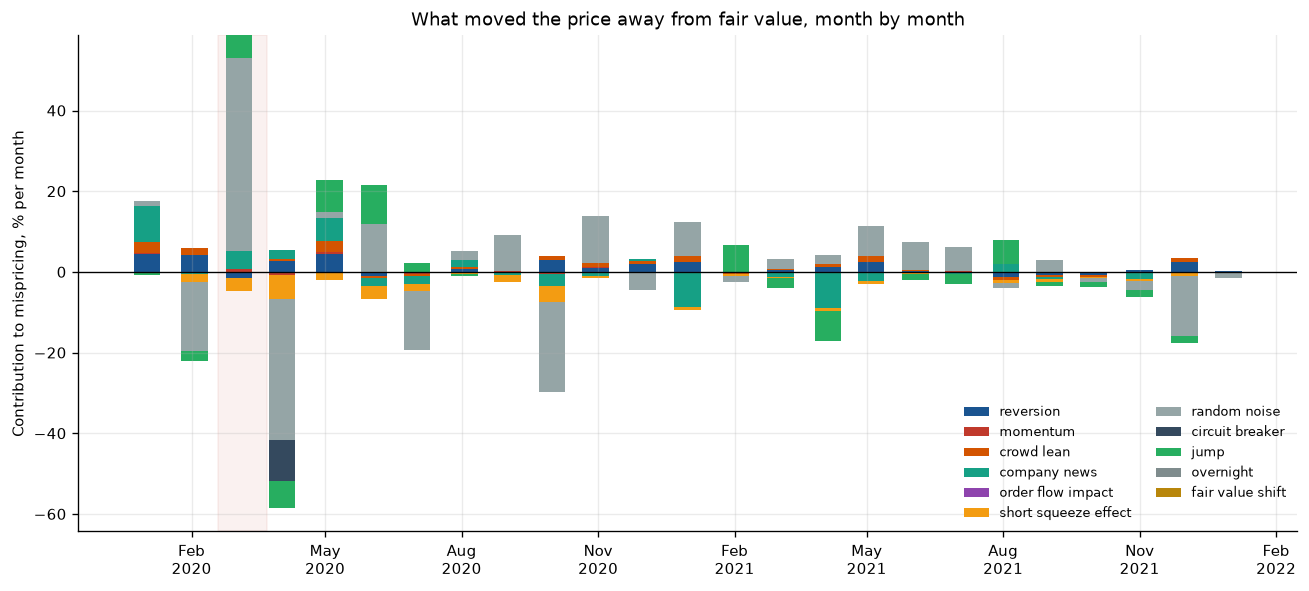

In [18]:
truth = pa.table(engine2.truth())
one = pc.filter(truth, pc.equal(truth["instrument_id"], 0))
daily = (one.group_by("day")
         .aggregate([(f, "sum") for f in tf.Engine.FACTORS]).sort_by("day"))

M = 21  # a month of sessions, so the chart reads as episodes not noise
series = {f: [sum(daily[f"{f}_sum"].to_pylist()[i:i + M]) * 100
              for i in range(0, N, M)] for f in tf.Engine.FACTORS}
buckets = [DATES[min(i, N - 1)] for i in range(0, N, M)]

fig, ax = plt.subplots(figsize=(11, 5))
# One colour per factor. `zip` stops at the shorter list, so a list one
# short of `tf.Engine.FACTORS` drops the last factor from the chart without
# a word; this had nine colours for ten factors until 0.8.0, and 0.8.5
# added the eleventh, fair_value_shift.
colours = ["#1a5490", "#c0392b", "#d35400", "#16a085", "#8e44ad",
           "#f39c12", "#95a5a6", "#34495e", "#27ae60", "#7f8c8d",
           "#b8860b"]
assert len(colours) == len(tf.Engine.FACTORS)
pos, neg = [0.0] * len(buckets), [0.0] * len(buckets)
for f, colour in zip(tf.Engine.FACTORS, colours):
    vals = series[f]
    base_ = [pos[i] if vals[i] >= 0 else neg[i] for i in range(len(vals))]
    ax.bar(buckets, vals, bottom=base_, width=18, color=colour,
           label=f.replace("_", " "), linewidth=0)
    for i, v in enumerate(vals):
        if v >= 0:
            pos[i] += v
        else:
            neg[i] += v

ax.axhline(0, color="black", lw=0.8)
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.set_ylabel("Contribution to mispricing, % per month")
ax.legend(loc="lower right", fontsize=7.5, ncol=2, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("What moved the price away from fair value, month by month",
             fontsize=11)
fig.tight_layout()
plt.show()

In [19]:
crash_days = [i for i, d in enumerate(DATES) if crash[0] <= d <= crash[1]]
calm_days = [i for i, d in enumerate(DATES)
             if dt.date(2021, 6, 1) <= d <= dt.date(2021, 9, 1)]

print(f"{'factor':24s} {'crash window':>14s} {'calm 2021':>14s}")
print("-" * 54)
for f in tf.Engine.FACTORS:
    v = daily[f"{f}_sum"].to_pylist()
    print(f"{f.replace('_', ' '):24s} "
          f"{sum(v[i] for i in crash_days) * 100:>13.2f}% "
          f"{sum(v[i] for i in calm_days) * 100:>13.2f}%")

close_tick = pc.filter(one, pc.equal(one["tick"], pc.max(one["tick"]))).to_pylist()
fund = {r["day"]: r["fundamental_value"] for r in close_tick}

print()
print(f"{'window':24s} {'mispricing':>14s} {'fundamental':>14s} {'price':>10s}")
print("-" * 66)
for name, idx in (("crash", crash_days), ("calm 2021", calm_days)):
    mis = sum(sum(daily[f"{f}_sum"].to_pylist()[i] for i in idx)
              for f in tf.Engine.FACTORS) * 100
    a, b = idx[0], idx[-1]
    print(f"{name:24s} {mis:>13.2f}% {(fund[b] / fund[a] - 1) * 100:>13.2f}% "
          f"{(sim2[b] / sim2[a] - 1) * 100:>9.2f}%")

print()
print(f"model fundamental value on {DATES[0]}: ${fund[0]:,.2f}")
print(f"actual market price that day:        ${AAPL[0]:,.2f}")
print(f"the model starts AAPL {fund[0] / AAPL[0] - 1:+.0%} above where it traded")

factor                     crash window      calm 2021
------------------------------------------------------
reversion                         2.99%         -1.17%
momentum                          0.42%          0.22%
crowd lean                        2.01%         -0.37%
company news                      5.90%          1.58%
order flow impact                 0.00%          0.00%
short squeeze effect             -3.50%         -1.30%
random noise                     21.41%         10.25%
circuit breaker                   0.00%          0.00%
jump                              4.72%          2.28%
overnight                         0.00%          0.00%
fair value shift                  0.00%          0.00%

window                       mispricing    fundamental      price
------------------------------------------------------------------
crash                            33.95%        -32.51%     -4.83%
calm 2021                        11.50%          0.73%     12.46%

model fundamental 

## The other lever: companies arriving and leaving

Everything so far moved prices by moving the macro state. The universe itself
is also a lever, and 2020-21 is the period where that matters most: after the
March crash the new issue market did not just reopen, it broke its own record.

| | 2019 | 2020 | 2021 |
|---|---|---|---|
| US IPOs | ~232 | ~480 | ~1,035 |
| of which SPACs | 59 | 248 | 613 |

`Engine.list_instrument` and `Engine.delist` express that: a company can start
trading part way through a run, and one can stop. The run below exercises the
arrival half only. It floats twelve new names across the boom window, priced at
a premium to their own fundamentals the way an enthusiastic new issue market
does, and delists nothing.

In [20]:
BOOM_START = dt.date(2020, 9, 1)
LISTINGS = 12

boom = [i for i, d in enumerate(DATES) if d >= BOOM_START]
listing_days = boom[::max(1, len(boom) // LISTINGS)][:LISTINGS]

scen2 = build(qe_v2)
engine3 = tf.Engine(seed=2020, universe=make_universe(), model=MODEL)
INCUMBENTS = engine3.len
listed_on = {}

for i in range(N):
    if i in listing_days:
        n = len(listed_on)
        cand = tf.Universe.random(1, seed=7000 + n)[0]
        newco = tf.Instrument(
            f"NEW{n:02d}", cand.sector,
            initial_price=cand.initial_price * 1.30,    # priced with enthusiasm
            shares_outstanding=cand.shares_outstanding,
            eps=cand.eps, book_value_per_share=cand.book_value_per_share,
            revenue_growth=cand.revenue_growth + 0.25,  # growth story
            avg_volume=cand.avg_volume, beta=cand.beta * 1.3,
            short_interest=cand.short_interest,
        )
        listed_on[engine3.list_instrument(newco)] = i
    scen2.apply(engine3, i)
    engine3.run_days(1, first_day=i)

print(f"{INCUMBENTS} incumbents, {len(listed_on)} new listings")
print(f"first listing {DATES[min(listed_on.values())]}, "
      f"last {DATES[max(listed_on.values())]}")

40 incumbents, 12 new listings
first listing 2020-09-01, last 2021-11-19


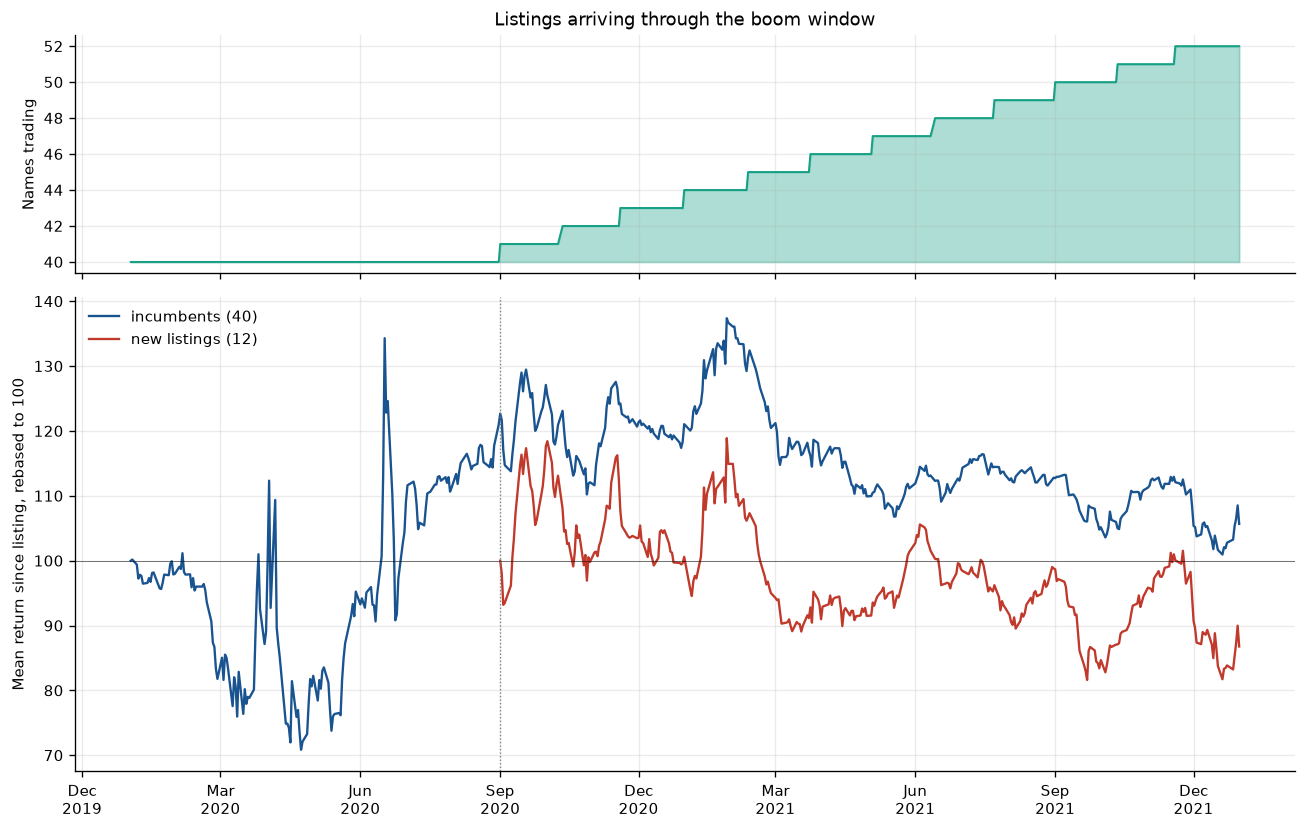

by 2021-12-31, mean return since listing:
  incumbents    +5.7%
  new listings  -13.2%


In [21]:
b3 = pa.table(engine3.bars(grain="day")).to_pylist()
by_day = {}
for r in b3:
    by_day.setdefault(r["day"], {})[r["instrument_id"]] = r["close"]
days_sorted = sorted(by_day)


def cohort_path(ids):
    out = []
    for d in days_sorted:
        vals = []
        for i in ids:
            start = listed_on.get(i, 0)
            if i in by_day[d] and start in by_day and i in by_day[start]:
                vals.append(by_day[d][i] / by_day[start][i])
        out.append(100 * st.mean(vals) if vals else None)
    return out


inc_ids, new_ids = list(range(INCUMBENTS)), list(listed_on)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 2]})
xs = [DATES[d] for d in days_sorted]
count = [len(by_day[d]) for d in days_sorted]
ax1.fill_between(xs, count, INCUMBENTS, color="#16a085", alpha=0.35)
ax1.plot(xs, count, color="#16a085", lw=1.2)
ax1.set_ylabel("Names trading")
ax1.set_title("Listings arriving through the boom window", fontsize=11)

ax2.plot(xs, cohort_path(inc_ids), color="#1a5490", lw=1.4,
         label=f"incumbents ({len(inc_ids)})")
ax2.plot(xs, cohort_path(new_ids), color="#c0392b", lw=1.4,
         label=f"new listings ({len(new_ids)})")
ax2.axhline(100, color="black", lw=0.6, alpha=0.5)
ax2.axvline(BOOM_START, color="grey", lw=0.8, ls=":")
ax2.set_ylabel("Mean return since listing, rebased to 100")
ax2.legend(loc="upper left", frameon=False)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
plt.show()

print(f"by {DATES[-1]}, mean return since listing:")
print(f"  incumbents    {cohort_path(inc_ids)[-1] - 100:+.1f}%")
print(f"  new listings  {cohort_path(new_ids)[-1] - 100:+.1f}%")

The new listings lag the incumbents, and they lag for a reason that was put
into the setup rather than discovered: they were floated at a 30% premium to
their own fundamentals, and reversion pulls a price back toward what the
company is worth. That is a mechanism reproducing an assumption rather than
evidence about real IPOs.

## One more lever: which sectors the universe is made of

2020 was twelve markets, not one. The dispersion across sectors was the
year's real story, and an equal weighted index hides all of it:

| S&P 500 sector | 2020 total return |
|---|---|
| Information Technology | +43.9% |
| Consumer Discretionary | +33.3% |
| Materials | +20.7% |
| Health Care | +13.5% |
| Consumer Staples | +10.8% |
| Utilities | +0.5% |
| Financials | -1.7% |
| Real Estate | -2.2% |
| Energy | -33.7% |

tradefloor carries twelve sectors and they are not cosmetic. The cell below holds
fundamentals, seed and macro path completely fixed and varies nothing but the
sector label, so whatever separates the lines is the sector itself.

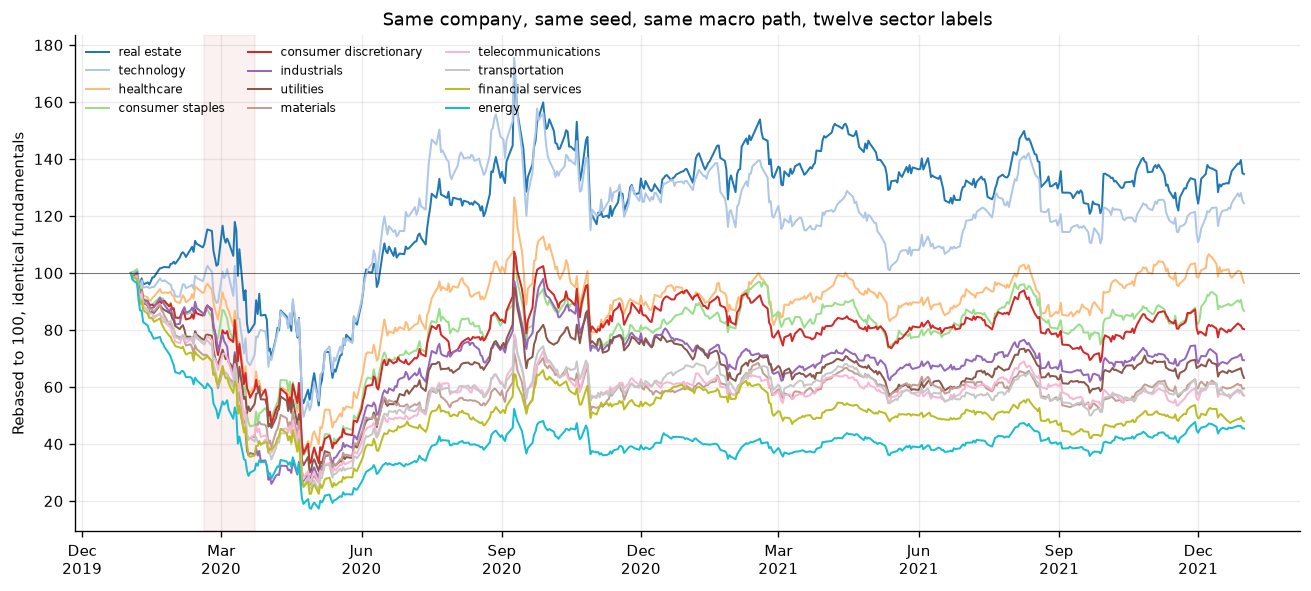

sector                       total return
------------------------------------------
real estate                       +34.8%
technology                        +24.5%
healthcare                         -3.4%
consumer staples                  -13.3%
consumer discretionary            -19.7%
industrials                       -30.6%
utilities                         -36.8%
materials                         -40.5%
telecommunications                -42.9%
transportation                    -43.0%
financial services                -52.0%
energy                            -54.5%

spread, best to worst: 89.3%


In [22]:
SECTORS = ["technology", "financial_services", "healthcare", "energy",
           "consumer_discretionary", "consumer_staples", "industrials",
           "materials", "real_estate", "utilities", "telecommunications",
           "transportation"]


def one_sector(sector):
    probe = tf.Instrument(
        "PROBE", sector, initial_price=100.0, shares_outstanding=1e9,
        eps=4.0, book_value_per_share=20.0, revenue_growth=0.05,
        avg_volume=5e6, beta=1.0, short_interest=1e6)
    u = tf.Universe([probe]); u.extend(tf.Universe.random(7, seed=44))
    e = tf.Engine(seed=2020, universe=u, model=MODEL)
    for i in range(N):
        scen2.apply(e, i)
        e.run_days(1, first_day=i)
    return closes(e)


paths = {s: one_sector(s) for s in SECTORS}
finals = sorted(((p[-1] / p[0] - 1, s) for s, p in paths.items()), reverse=True)

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.get_cmap("tab20")
for n, (_, s) in enumerate(finals):
    p = paths[s]
    ax.plot(DATES, [100 * v / p[0] for v in p], lw=1.2, color=cmap(n / 12),
            label=s.replace("_", " "))
ax.axhline(100, color="black", lw=0.6, alpha=0.5)
ax.axvspan(*crash, color="#c0392b", alpha=0.07, zorder=0)
ax.set_ylabel("Rebased to 100, identical fundamentals")
ax.legend(loc="upper left", fontsize=7, ncol=3, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_title("Same company, same seed, same macro path, twelve sector labels",
             fontsize=11)
fig.tight_layout()
plt.show()

print(f"{'sector':26s} {'total return':>14s}")
print("-" * 42)
for r, s in finals:
    print(f"{s.replace('_', ' '):26s} {r:>+13.1%}")
print()
print(f"spread, best to worst: {finals[0][0] - finals[-1][0]:.1%}")

Nothing varies but the label, and the spread is wide. Sector is doing real work
in this model.

The ends of the ranking are recognisable. Technology finishes near the top and
energy finishes last, the shape 2020 actually had. The middle of the ranking
does not correspond at all: real estate comes first here against roughly flat
in reality, and with twelve sectors and one seed the extremes agreeing is weak
evidence.

What the model is **not** doing is reproducing 2020. The ordering is its own
sector dynamics under this macro path. There is no field that makes energy fall
because oil went negative in April 2020, and nothing told the model that a
pandemic is good for software and bad for aircraft.

So this lever works through composition rather than instruction. If you want a
universe that behaves like 2020's market, you choose what the universe is made
of and accept the dynamics the model attaches to each sector. That is a
weaker claim than driving it, and worth knowing before building a study on top
of it.

## What to take from this

Four real macro series produced a crash on the wrong dates and about twenty
points deeper than the real one. Sweeping the fields one at a time showed why:
of the four, only `corporate_bond_yield` and `qe_pe_boost` reach a valuation at
all, the credit leg is worth about 1% over its 2020 rise against a 34%
fall, and the one lever large enough to carry the rest had been pinned at zero
through the entire crash. Supplying the market's real valuation path took
the daily return correlation against Apple from -0.048 to +0.269, and the index
against the S&P from -0.030 to +0.392. It did not move the trough, and it did
not fix the depth.

A scenario is only as good as the channel it reaches the model through. Adding
more real series does not help if they enter through fields that do not
connect, and sweeping them is how you find out which do.

### Which levers are worth pulling

Measured above, or measured the same way:

| lever | verdict |
|---|---|
| `qe_pe_boost` | the load bearing one on `pt-v12`. Linear, signed, and the only channel that bypasses the discount rate. Inert from `pt-v16` on, where `qe_pe_gain` is 0.0 |
| `corporate_bond_yield` | the discount rate, and the sole route for everything upstream of it. Baa's 2020 rise as a monthly series, 3.77% to 4.28%, is worth about 1% |
| `federal_funds_rate` | strong but conditional and slow. Unpinned it is worth about 10% at a 10% rate, and on `pt-v12` it arrives in one step at the first rate-setting meeting, day 45, rather than building up. On `pt-v19` it builds from day 8. Pin the corporate bond yield and it is severed completely |
| `vix` | same story, much weaker. Reaches valuation only through the yield, and shapes volatility directly |
| `inflation_rate` | the yield again, but not on the same clock: a big enough gap to the policy rate makes the bank move the yield the same day instead of waiting for its calendar. Pin the yield to something real, as here, and that route is severed, so pinning inflation as well changes nothing at all |
| `fear_greed_index` | genuinely inert. Bit identical prices at every value from 0 to 100 out to 504 days, and no pricing code reads it |
| `gdp_growth`, `unemployment_rate` | reported in `macro_table` but not settable |
| `list_instrument`, `delist` | both live. `list_instrument` floats twelve names above; `delist` is not exercised anywhere in this notebook |
| `sector` | large. Holding everything else fixed, the label alone spreads two year returns by 89 points |
| `short_interest` | close to inert. Taking it from zero to 200 million shares moves a 120 day price by about two hundredths of a percent, so a squeeze is not reachable this way |
| `run_days(volatility=...)` | live, a per run multiplier on how violently the session moves |

### What it still cannot do

*The company.* The two year total return, +19.3%, remains far short of Apple's
+136.5%, and no macro path will close it. Apple more than doubled because
revenue grew from $260bn to $366bn; the model was handed the FY2019 accounts
and never told what came next. Macro explains the crisis, not the company.

*The starting valuation.* Apple's real FY2019 accounts put the model's
fundamental value about 27% above where the shares actually traded on 2 January
2020, so the run carries an upward reversion pull the real market did not have.
Rescaling the accounts to remove it was tried and makes the overall fit worse,
which is its own warning about tuning inputs to improve a score.

*Volatility, once the valuation path is supplied.* Realised volatility comes
out at 63.5% against Apple's 37.4%, because a jumpy real index is now feeding
fair value as well as sentiment. Smoothing it away costs the timing that made
the repair worth making, so this one is a genuine trade rather than an
oversight.

*Independent validation, now.* Once the market valuation path is an input, the
simulated index tracking the real one is partly definitional. AAPL remains the
honest test, and even it inherits the market factor.

**And one caveat about the horizon.** The run is 505 days; tradefloor's envelope
is certified at 252, so a two year run is outside what the certification
covers. That is a judgement rather than a guarantee.

This notebook pins `pt-v12`, the default from 0.3.0 until `pt-v14` replaced it
at 0.4.0. The shipped default is `pt-v20` (0.8.5). On its record,
`tf.preset_record("pt-v12")`, it holds 14 of 14 shape rows in band at one
year and 12 at two, where `abs_return_acf1` is out and `corr_persistence_acf1`
has no ruled band. Earlier versions of this notebook pinned `pt-v6`, which no
longer holds the most statistics of anything on offer.

*Other presets fit this path better than `pt-v12`.* The second attempt,
re-run under a series of presets, changing nothing but the name. The `pt-v12`
column is the run printed in this notebook; the others were measured the same
way on 0.8.5, on this path with the monthly Baa. On `pt-v19` and `pt-v20` the valuation path
reaches nothing, so their columns are the first attempt:

| | pt-v3 | pt-v6 | pt-v9 | pt-v10 | pt-v12 | pt-v19 | pt-v20 | actual |
|---|---|---|---|---|---|---|---|---|
| realised vol against the VIX input | +0.709 | +0.717 | +0.675 | +0.657 | +0.645 | +0.550 | +0.538 | |
| AAPL level correlation | +0.809 | +0.772 | +0.706 | +0.733 | +0.614 | +0.316 | +0.749 | |
| AAPL daily return correlation | +0.410 | +0.401 | +0.327 | +0.299 | +0.269 | -0.068 | -0.101 | |
| index against the S&P, daily | +0.596 | +0.597 | +0.479 | +0.451 | +0.392 | -0.049 | -0.076 | |
| annualised volatility | 45.2% | 47.6% | 51.7% | 56.5% | 63.5% | 39.2% | 41.5% | 37.4% |
| maximum drawdown | -30.1% | -28.2% | -34.7% | -41.1% | -49.3% | -35.8% | -25.5% | -31.4% |
| date of the trough | 2020-03-12 | 2020-03-09 | 2020-10-27 | 2020-05-13 | 2020-05-13 | 2020-05-18 | 2020-05-18 | 2020-03-23 |

pt-v6 fits this path better than `pt-v12` on every row. That is worth
understanding rather than explaining away, and mostly about what a
single name can show.

The trough date moves with the seed, so read that row lightly: each entry is a
single draw. The drawdown gap is not the same kind of artefact. `pt-v12` runs a
great deal deeper than pt-v6 on this path, -49.3% against -28.2%, because its
market reacts to its own moves and this path hands it a violent year.

The `pt-v19` and `pt-v20` columns are the odd ones out, and the next section
explains them.

The correlations are a genuine trade. `pt-v12` was calibrated on a
cross-section of forty names measured against real-market bands, and it wins
there: on the preset records, 14 of 14 shape rows in band at one year against
pt-v6's 12. This notebook measures one real company against thirty-nine
generated ones, which is not what that calibration optimises. If your study is
a single name against a real path, `model="pt-v6"` is defensible and you can
say why. If it is anything cross-sectional, the default, `pt-v20`, is the
better market.

The transient penalty does not bite here. `scenario_response.py` measures the
reaction to a twenty-day spike; this notebook supplies the VIX every day for
505 days. Tracking a path and reacting to a shock are different jobs, which is
how two presets 11 points apart on that instrument land within 0.01 of each
other on the first row of this table.

## The same path on the default

`pt-v20` is the shipped default from 0.8.5. The cell below runs both attempts
on it, changing nothing but the preset.

In [23]:
DEFAULT = tf.model_preset()["name"]


def qe_gain(preset):
    return tf.ModelParams.from_preset(preset).to_dict()["qe_pe_gain"]


d1 = run(build(qe_v1), model=DEFAULT)
d2 = run(build(qe_v2), model=DEFAULT)
print(f"qe_pe_gain: {qe_gain(MODEL)} on {MODEL}, {qe_gain(DEFAULT)} on {DEFAULT}")
print(f"attempt 2 identical to attempt 1 on {DEFAULT}: "
      f"{closes(d1) == closes(d2)}")
print()
scorecard(closes(d2), index_of(d2), f"Both attempts on {DEFAULT}")


def from_the_high(level):
    # The reading pt-v20's registered row D2 takes: the highest close of the
    # first 40 sessions, the lowest close after it, and the sessions until
    # the level is back at that high.
    k = max(range(40), key=lambda i: level[i])
    t = min(range(k, N), key=lambda i: level[i])
    back = next((i - k for i in range(t, N) if level[i] >= level[k]), None)
    return k, t, back


idx_d = index_of(d2)
print()
for name, level in (("simulated index", idx_d), ("S&P 500", SPX)):
    k, t, back = from_the_high(level)
    print(f"{name:16s} high {DATES[k]}, low {DATES[t]}, "
          f"fall {1 - level[t] / level[k]:.1%}, back in {back} sessions, "
          f"two years {level[-1] / level[0] - 1:+.1%}")
w, at = max_drawdown(idx_d)
print(f"simulated index, deepest fall anywhere: {w:.1%}, to {DATES[at]}")

qe_pe_gain: 1.0 on pt-v12, 0.0 on pt-v20


attempt 2 identical to attempt 1 on pt-v20: True



Both attempts on pt-v20
--------------------------------------------------------------
                                    simulated         actual
annualised volatility                   41.5%          37.4%
maximum drawdown                       -25.5%         -31.4%
date of the trough                 2020-05-18     2020-03-23
total return                           +40.6%        +136.5%

AAPL, level correlation                +0.749
AAPL, daily return corr                -0.101
index vs S&P, level corr               +0.912
index vs S&P, daily corr               -0.076

simulated index  high 2020-01-03, low 2020-03-03, fall 17.0%, back in 62 sessions, two years +60.9%
S&P 500          high 2020-02-19, low 2020-03-23, fall 33.9%, back in 126 sessions, two years +46.3%
simulated index, deepest fall anywhere: -18.9%, to 2020-05-19


On the default the valuation path reaches nothing, so the two attempts are the
same run. Volatility is close, 41.5% against Apple's 37.4%, and the drawdown
is shallower than the real one, -25.5% against -31.4%. The trough lands on 18
May 2020, eight weeks after the real one, and the daily returns do not track
Apple's, -0.101. The level correlation is +0.749, and the two years end up
40.6% against Apple's 136.5%.

The whole simulated index falls less than the real one and sooner. Its high
of the first forty sessions is on 3 January, and it falls 17.0% to 3 March,
where the S&P fell 33.9% from 19 February to 23 March. It is back at that
high 62 sessions later, where the S&P took 126. It then falls again, 18.9%
from 1 May to 19 May, and ends the two years up 60.9% against the S&P's
46.3%, with a level correlation of +0.912.

That is one seed on this notebook's roster, averaged by price, with Baa as
a monthly line. pt-v20's graded row for this path, D2, drives the daily path
through the certified
40-name roster, weighted by market value, over 90 histories, and its median
reads a drawdown of 0.374 against the S&P's 0.339 and 120.5 sessions back to
the pre-crash high against 126 (grade ptv20g6). This seed is far milder than
that median.

The path carries the business cycle as well, from the NBER dates (`phases`
above): a peak until February 2020, contraction in March, trough in April,
recovery until spring 2021 and expansion after. That matters on pt-v20,
whose aggregate earnings follow the cycle. When the path left the phase out
and took its credit leg from the high-yield proxy, the model ran its own
cycle, stayed in contraction through 2021, and this seed's index fell 58.3%
and never recovered. On `pt-v12` the cycle changes nothing in this notebook.

The channel is off on purpose. A gain fitted to a proxy that anticorrelates
with the real series would encode the proxy as if it were the model's
physics, so from `pt-v16` on the channel is closed. On the default a real
crisis reaches valuations through the discount rate, `corporate_bond_yield`,
and the earnings cycle, which follows the path's cycle phase. Part 2 put
Baa's monthly 2020 rise at about 1% of fundamental value on `pt-v12`.

### Where to go next

- `04-how-realistic-is-this.ipynb` for what the envelope certifies and what it
  admits it does not.
- `03-why-did-the-price-move.ipynb` for the attribution machinery used above.
- The [Scenarios page](https://docs.tradefloor.dev/scenarios.html) for the
  scenario surface and what each field transmits.